# Étape 2 — Expériences de chunking

Ce notebook est une **version expérimentale**, pas encore la configuration finale. Il génère quatre stratégies (`fixed_v1`, `structure_aware_v1`, `section_preserving_v1`, `hierarchical_v1`), mesure leurs propriétés intrinsèques et produit des artefacts versionnés. Le choix final sera fait après inspection de ces résultats puis évaluation du retrieval.

Les conversations ne sont jamais utilisées pour créer les chunks : seuls les 488 documents canoniques de l’étape 1 entrent dans ce pipeline.

## 1. Dépendances

In [1]:
%pip install -q pandas matplotlib tiktoken

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import hashlib
import json
import re
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import tiktoken
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
INPUT_DIR = PROJECT_ROOT / "data" / "processed" / "multidoc2dial_v1"
CONFIG_PATH = PROJECT_ROOT / "configs" / "chunking_experiments.json"

print(f"Project root : {PROJECT_ROOT}")
print(f"Input        : {INPUT_DIR}")
print(f"Configuration: {CONFIG_PATH}")

Project root : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant
Input        : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\processed\multidoc2dial_v1
Configuration: C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\configs\chunking_experiments.json


## 2. Chargement strict de l’étape 1 et de la configuration

In [3]:
def load_json(path: Path) -> dict[str, Any]:
    with path.open(encoding="utf-8") as handle:
        value = json.load(handle)
    if not isinstance(value, dict):
        raise TypeError(f"La racine de {path} doit être un objet JSON")
    return value


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    records = []
    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise ValueError(f"JSONL invalide dans {path}, ligne {line_number}") from error
    return records


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def stable_hash(value: Any) -> str:
    payload = json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


config = load_json(CONFIG_PATH)
config_hash = stable_hash(config)
experiment_id = f"{config['experiment_name']}_{config_hash[:10]}"
OUTPUT_ROOT = INPUT_DIR / "chunking_experiments" / experiment_id
REPORT_ROOT = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1" / "chunking_experiments" / experiment_id

input_manifest = load_json(INPUT_DIR / "manifest.json")
if input_manifest.get("quality", {}).get("status") != "passed":
    raise RuntimeError(
        "Les artefacts de l’étape 1 ne correspondent pas à sa version finale. "
        "Relance d’abord 01_data_analysis_validation.ipynb avec Restart Kernel > Run All."
    )

documents_path = INPUT_DIR / "documents.jsonl"
expected_hash = input_manifest["outputs"]["documents.jsonl"]["sha256"]
assert file_sha256(documents_path) == expected_hash, "documents.jsonl ne correspond pas au manifeste"
documents = load_jsonl(documents_path)
assert len(documents) == input_manifest["outputs"]["documents.jsonl"]["records"]

for document in documents:
    for section in document["sections"]:
        if "offset_semantics" not in section:
            raise RuntimeError("Champ offset_semantics absent : relance le notebook 01 final.")
        for span in section["spans"]:
            if "within_section_range" not in span:
                raise RuntimeError("Champ within_section_range absent : relance le notebook 01 final.")

print(f"Experiment ID : {experiment_id}")
print(f"Documents     : {len(documents):,}")
print(f"Input SHA-256 : {expected_hash}")

Experiment ID : chunking_candidates_v0_b1ac9cc451
Documents     : 488
Input SHA-256 : 21f704ddab631dfc99e59eab88887bb020a670f046f81aba7ac0a167afebad6b


## 3. Profil token-level avant chunking

In [4]:
ENCODING = tiktoken.get_encoding(config["tokenizer"]["encoding"])


def token_count(text: str) -> int:
    return len(ENCODING.encode(text, disallowed_special=()))


document_profile = []
section_profile = []
span_profile = []
for document in documents:
    document_profile.append(
        {"document_id": document["id"], "domain": document["domain"], "tokens": token_count(document["text"])}
    )
    for section in document["sections"]:
        section_profile.append(
            {
                "document_id": document["id"],
                "section_id": section["id"],
                "domain": document["domain"],
                "tokens": token_count(section["text"]),
                "offset_semantics": section["offset_semantics"],
            }
        )
        for span in section["spans"]:
            span_profile.append(
                {
                    "document_id": document["id"],
                    "section_id": section["id"],
                    "span_id": span["id"],
                    "domain": document["domain"],
                    "tokens": token_count(span["text"]),
                    "within_section_range": span["within_section_range"],
                }
            )

documents_tokens_df = pd.DataFrame(document_profile)
sections_tokens_df = pd.DataFrame(section_profile)
spans_tokens_df = pd.DataFrame(span_profile)
display(documents_tokens_df.groupby("domain")["tokens"].describe(percentiles=[0.5, 0.95, 0.99]).round(1))
display(sections_tokens_df["tokens"].describe(percentiles=[0.5, 0.95, 0.99]).round(1).to_frame())
display(spans_tokens_df["tokens"].describe(percentiles=[0.5, 0.95, 0.99]).round(1).to_frame())
print(f"Spans > 300 tokens  : {(spans_tokens_df['tokens'] > 300).sum():,}")
print(f"Sections > 1 200   : {(sections_tokens_df['tokens'] > 1200).sum():,}")

,count,mean,std,min,50%,95%,99%,max
domain,,,,,,,,
dmv,149.0,1036.0,725.3,224.0,885.0,2132.4,4006.6,5618.0
ssa,109.0,852.7,515.8,166.0,663.0,1870.0,2363.0,2402.0
studentaid,92.0,1127.9,1150.0,200.0,703.0,2666.7,4719.1,8603.0
va,138.0,900.5,421.0,238.0,803.5,1638.3,1910.7,2772.0


,tokens
count,13421.0
mean,36.1
std,40.6
min,2.0
50%,24.0
95%,106.0
99%,186.6
max,701.0


,tokens
count,35659.0
mean,14.2
std,9.5
min,2.0
50%,12.0
95%,32.0
99%,46.0
max,99.0


Spans > 300 tokens  : 0
Sections > 1 200   : 0


## 4. Déduplication exacte avec conservation des alias

In [5]:
def normalized_text(text: str) -> str:
    return " ".join(text.casefold().split())


def structural_signature(document: dict[str, Any]) -> str:
    structure = [
        {
            "title": section["title"],
            "parent_titles": section["parent_titles"],
            "text": section["text"],
            "start_char": section["start_char"],
            "end_char": section["end_char"],
            "spans": [
                {
                    "source_tag": span["source_tag"],
                    "text": span["text"],
                    "start_char": span["start_char"],
                    "end_char": span["end_char"],
                    "within_section_range": span["within_section_range"],
                }
                for span in section["spans"]
            ],
        }
        for section in document["sections"]
    ]
    return stable_hash(structure)


documents_by_hash: dict[str, list[dict[str, Any]]] = defaultdict(list)
for document in documents:
    documents_by_hash[document["content_hash"]].append(document)

document_groups = []
for content_hash, aliases in sorted(documents_by_hash.items()):
    aliases = sorted(aliases, key=lambda item: item["id"])
    signatures = {structural_signature(document) for document in aliases}
    if len(signatures) != 1:
        raise ValueError(f"Documents de même contenu mais de structures différentes : {content_hash}")
    domains = {document["domain"] for document in aliases}
    if len(domains) != 1:
        raise ValueError(f"Doublon présent dans plusieurs domaines : {content_hash}")

    all_spans = []
    for alias in aliases:
        for section in alias["sections"]:
            for span in section["spans"]:
                all_spans.append(
                    {
                        "span_id": span["id"],
                        "section_id": section["id"],
                        "source_tag": span["source_tag"],
                        "text": span["text"],
                        "start_char": span["start_char"],
                        "end_char": span["end_char"],
                    }
                )

    document_groups.append(
        {
            "content_hash": content_hash,
            "representative": aliases[0],
            "aliases": aliases,
            "all_spans": all_spans,
        }
    )

duplicate_groups = sum(len(group["aliases"]) > 1 for group in document_groups)
print(f"Documents source       : {len(documents):,}")
print(f"Contenus uniques       : {len(document_groups):,}")
print(f"Groupes avec doublons  : {duplicate_groups:,}")
print(f"Copies évitées         : {len(documents) - len(document_groups):,}")

Documents source       : 488
Contenus uniques       : 475
Groupes avec doublons  : 10
Copies évitées         : 13


## 5. Primitives déterministes de découpage et de traçabilité

In [6]:
UNIT_PATTERN = re.compile(r"\S+\s*|\s+")


def canonical_id(entity: str, *parts: str) -> str:
    payload = "\x1f".join((entity, *parts)).encode("utf-8")
    return f"{entity}_{hashlib.sha256(payload).hexdigest()[:24]}"


def split_oversized_unit(text: str, start: int, end: int, max_tokens: int) -> list[tuple[int, int]]:
    pieces = []
    cursor = start
    while cursor < end:
        low, high, best = cursor + 1, end, None
        while low <= high:
            middle = (low + high) // 2
            if token_count(text[cursor:middle]) <= max_tokens:
                best = middle
                low = middle + 1
            else:
                high = middle - 1
        if best is None:
            raise ValueError("Impossible de découper une unité dans la limite de tokens")
        pieces.append((cursor, best))
        cursor = best
    return pieces


def text_windows(text: str, max_tokens: int, overlap_tokens: int) -> list[dict[str, Any]]:
    if not text:
        return []
    units = []
    for match in UNIT_PATTERN.finditer(text):
        if token_count(match.group()) <= max_tokens:
            units.append((match.start(), match.end()))
        else:
            units.extend(split_oversized_unit(text, match.start(), match.end(), max_tokens))

    windows = []
    start_index = 0
    while start_index < len(units):
        low, high, best_end = start_index + 1, len(units), start_index + 1
        char_start = units[start_index][0]
        while low <= high:
            middle = (low + high) // 2
            candidate_end = units[middle - 1][1]
            if token_count(text[char_start:candidate_end]) <= max_tokens:
                best_end = middle
                low = middle + 1
            else:
                high = middle - 1
        char_end = units[best_end - 1][1]
        content = text[char_start:char_end]
        windows.append({"text": content, "ranges": [(char_start, char_end)]})
        if best_end == len(units):
            break

        next_start = best_end
        for candidate in range(best_end - 1, start_index, -1):
            overlap = text[units[candidate][0]:char_end]
            if token_count(overlap) <= overlap_tokens:
                next_start = candidate
            else:
                break
        start_index = next_start if next_start > start_index else best_end
    return windows


def merge_ranges(ranges: list[tuple[int, int]]) -> list[tuple[int, int]]:
    merged = []
    for start, end in sorted(set(ranges)):
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return [(start, end) for start, end in merged]


def overlap_length(start: int, end: int, ranges: list[tuple[int, int]]) -> int:
    return sum(max(0, min(end, range_end) - max(start, range_start)) for range_start, range_end in ranges)


def collect_evidence(
    group: dict[str, Any], ranges: list[tuple[int, int]], title_paths: list[list[str]]
) -> list[dict[str, Any]]:
    ranges = merge_ranges(ranges)
    normalized_titles = {normalized_text(title) for path in title_paths for title in path}
    evidence = []
    for span in group["all_spans"]:
        span_size = span["end_char"] - span["start_char"]
        covered = overlap_length(span["start_char"], span["end_char"], ranges)
        title_match = str(span.get("source_tag", "")).startswith("h") and normalized_text(span["text"]) in normalized_titles
        if covered > 0 or title_match or (span_size == 0 and any(a <= span["start_char"] <= b for a, b in ranges)):
            coverage = 1.0 if title_match or span_size == 0 else min(1.0, covered / span_size)
            evidence.append(
                {
                    "span_id": span["span_id"],
                    "section_id": span["section_id"],
                    "coverage": round(coverage, 6),
                    "evidence_origin": "title_path" if title_match and covered == 0 else "content_range",
                }
            )
    return sorted(evidence, key=lambda item: (item["span_id"], item["section_id"]))


def section_title_path(section: dict[str, Any]) -> list[str]:
    values = [str(item.get("text", "")).strip() for item in section["parent_titles"]]
    if section.get("title"):
        values.append(str(section["title"]).strip())
    result = []
    for value in values:
        if value and (not result or normalized_text(value) != normalized_text(result[-1])):
            result.append(value)
    return result


def make_chunk(
    group: dict[str, Any], strategy_name: str, strategy_config: dict[str, Any], level: str,
    position: int, content: str, ranges: list[tuple[int, int]], title_paths: list[list[str]],
    parent_id: str | None = None,
) -> dict[str, Any]:
    representative = group["representative"]
    content = content.strip()
    if not content:
        raise ValueError(f"Chunk vide : {strategy_name}, {representative['id']}, position {position}")
    evidence = collect_evidence(group, ranges, title_paths)
    prefixes = []
    if strategy_config.get("prepend_document_title"):
        prefixes.append(f"Document: {representative['title']}")
    if strategy_config.get("prepend_section_path") and len(title_paths) == 1:
        path_text = " > ".join(title_paths[0])
        if normalized_text(path_text) != normalized_text(content):
            prefixes.append(f"Section: {path_text}")
    embedding_text = "\n".join([*prefixes, content])
    content_hash = hashlib.sha256(normalized_text(content).encode("utf-8")).hexdigest()
    chunk_id = canonical_id(
        "chunk", experiment_id, strategy_name, level, group["content_hash"], str(position), content_hash
    )
    return {
        "schema_version": "1.0.0",
        "id": chunk_id,
        "experiment_id": experiment_id,
        "implementation_version": config["implementation_version"],
        "strategy": strategy_name,
        "level": level,
        "parent_id": parent_id,
        "position": position,
        "domain": representative["domain"],
        "document_id": representative["id"],
        "document_aliases": [item["id"] for item in group["aliases"]],
        "source_document_ids": [item["provenance"]["source_document_id"] for item in group["aliases"]],
        "document_title": representative["title"],
        "title_path": title_paths[0] if len(title_paths) == 1 else [],
        "title_paths": title_paths,
        "content": content,
        "embedding_text": embedding_text,
        "token_count": token_count(content),
        "embedding_token_count": token_count(embedding_text),
        "content_hash": content_hash,
        "source_ranges": [{"start_char": start, "end_char": end} for start, end in merge_ranges(ranges)],
        "source_section_ids": sorted({item["section_id"] for item in evidence}),
        "source_span_ids": sorted({item["span_id"] for item in evidence}),
        "fully_contained_span_ids": sorted(
            {item["span_id"] for item in evidence if item["coverage"] >= 0.999999}
        ),
        "source_spans": evidence,
    }

## 6. Baseline fixed-size

In [7]:
def build_fixed_chunks(strategy_name: str, strategy_config: dict[str, Any]) -> list[dict[str, Any]]:
    chunks = []
    for group in document_groups:
        text = group["representative"]["text"]
        windows = text_windows(text, strategy_config["max_tokens"], strategy_config["overlap_tokens"])
        for position, window in enumerate(windows):
            chunks.append(
                make_chunk(
                    group, strategy_name, strategy_config, "flat", position,
                    window["text"], window["ranges"], [], None,
                )
            )
    return chunks

## 7. Construction structure-aware, section-preserving et hiérarchique

Les spans restent atomiques et chaque changement de section est matérialisé par son chemin de titres. `structure_aware_v1` compacte les spans vers 220 tokens. `section_preserving_v1` traite chaque section complète comme une unité indivisible tant que son rendu ne dépasse pas 800 tokens, puis regroupe ces unités jusqu’à environ 600 tokens ; seules les sections dépassant réellement 800 tokens peuvent être divisées. Les parents hiérarchiques sont construits à l’échelle du document, puis redécoupés en children.

In [8]:
def section_atoms(section: dict[str, Any], max_tokens: int) -> list[dict[str, Any]]:
    valid_spans = [span for span in section["spans"] if span["within_section_range"]]
    valid_spans.sort(key=lambda item: (item["start_char"], item["end_char"], item["id"]))
    reconstructed = normalized_text(" ".join(span["text"] for span in valid_spans))
    if reconstructed != normalized_text(section["text"]):
        raise ValueError(f"Reconstruction de section impossible : {section['id']}")

    atoms = []
    for span in valid_spans:
        windows = text_windows(span["text"], max_tokens, 0)
        for fragment_index, window in enumerate(windows):
            local_start = window["ranges"][0][0]
            local_end = window["ranges"][0][1]
            text = window["text"].strip()
            if not text:
                continue
            # Le texte visible est nettoyé, mais la plage conserve aussi les espaces source.
            # Ainsi un span inclus comme unité atomique obtient bien une couverture de 100 %.
            global_start = span["start_char"] + local_start
            global_end = span["start_char"] + local_end
            atoms.append(
                {
                    "text": text,
                    "ranges": [(global_start, global_end)],
                    "section_id": section["id"],
                    "title_path": section_title_path(section),
                    "fragmented_span": len(windows) > 1,
                    "fragment_index": fragment_index,
                }
            )
    return atoms


def render_atoms(atoms: list[dict[str, Any]]) -> str:
    lines = []
    previous_section_id = None
    for atom in atoms:
        if atom["section_id"] != previous_section_id:
            path_text = " > ".join(atom["title_path"])
            if path_text and normalized_text(path_text) != normalized_text(atom["text"]):
                lines.append(f"Section: {path_text}")
            previous_section_id = atom["section_id"]
        lines.append(atom["text"])
    return "\n".join(lines).strip()


def pack_title_paths(pack: list[dict[str, Any]]) -> list[list[str]]:
    paths = []
    seen = set()
    for atom in pack:
        key = tuple(atom["title_path"])
        if key not in seen:
            paths.append(list(key))
            seen.add(key)
    return paths


def pack_atoms(
    atoms: list[dict[str, Any]], target_tokens: int, max_tokens: int,
    overlap_tokens: int = 0, max_overlap_tokens: int = 0, min_tokens: int = 0,
) -> list[list[dict[str, Any]]]:
    if not atoms:
        return []

    # 1) Packs disjoints : le rééquilibrage doit précéder l'ajout de l'overlap.
    base_packs = []
    start = 0
    while start < len(atoms):
        end = start + 1
        while end < len(atoms):
            candidate = render_atoms(atoms[start:end + 1])
            if token_count(candidate) > target_tokens:
                break
            end += 1
        pack = atoms[start:end]
        if token_count(render_atoms(pack)) > max_tokens:
            raise ValueError("Un pack dépasse max_tokens malgré le pré-découpage des spans")
        base_packs.append(pack)
        start = end

    # 2) Un dernier fragment trop court est fusionné ou rééquilibré avec son voisin.
    if min_tokens and len(base_packs) > 1 and token_count(render_atoms(base_packs[-1])) < min_tokens:
        combined = [*base_packs[-2], *base_packs[-1]]
        if token_count(render_atoms(combined)) <= max_tokens:
            base_packs[-2] = combined
            base_packs.pop()
        else:
            previous, tail = base_packs[-2], base_packs[-1]
            while token_count(render_atoms(tail)) < min_tokens and len(previous) > 1:
                candidate_previous = previous[:-1]
                candidate_tail = [previous[-1], *tail]
                if token_count(render_atoms(candidate_previous)) < min_tokens:
                    break
                if token_count(render_atoms(candidate_tail)) > max_tokens:
                    break
                previous, tail = candidate_previous, candidate_tail
            base_packs[-2], base_packs[-1] = previous, tail

    # 3) Overlap ajouté après rééquilibrage, uniquement s'il respecte max_tokens.
    if not overlap_tokens or len(base_packs) < 2:
        return base_packs
    overlap_limit = min(overlap_tokens, max_overlap_tokens or overlap_tokens)
    packs_with_overlap = [base_packs[0]]
    for previous, current in zip(base_packs, base_packs[1:]):
        overlap_atoms = []
        for atom in reversed(previous):
            candidate_overlap = [atom, *overlap_atoms]
            if token_count(render_atoms(candidate_overlap)) > overlap_limit:
                break
            if token_count(render_atoms([*candidate_overlap, *current])) > max_tokens:
                break
            overlap_atoms = candidate_overlap
        packs_with_overlap.append([*overlap_atoms, *current])
    return packs_with_overlap


def pack_ranges(pack: list[dict[str, Any]]) -> list[tuple[int, int]]:
    return merge_ranges([source_range for atom in pack for source_range in atom["ranges"]])


def build_structure_chunks(strategy_name: str, strategy_config: dict[str, Any]) -> list[dict[str, Any]]:
    chunks = []
    for group in document_groups:
        sections = sorted(
            group["representative"]["sections"],
            key=lambda item: (item["start_char"], item["end_char"], item["id"]),
        )
        document_atoms = []
        for section in sections:
            document_atoms.extend(section_atoms(section, strategy_config["max_tokens"]))
        packs = pack_atoms(
            document_atoms, strategy_config["target_tokens"], strategy_config["max_tokens"],
            strategy_config["overlap_tokens"], strategy_config["max_overlap_tokens"], strategy_config["min_tokens"],
        )
        for position, pack in enumerate(packs):
            chunks.append(
                make_chunk(
                    group, strategy_name, strategy_config, "flat", position,
                    render_atoms(pack), pack_ranges(pack), pack_title_paths(pack), None,
                )
            )
    return chunks


def pack_section_units(
    units: list[dict[str, Any]], target_tokens: int, max_tokens: int, min_tokens: int,
) -> list[list[dict[str, Any]]]:
    """Regroupe des sections entières ; une unité n'est jamais coupée par cette fonction."""
    if not units:
        return []

    packs: list[list[dict[str, Any]]] = []
    current: list[dict[str, Any]] = []
    for unit in units:
        if token_count(render_atoms(unit["atoms"])) > max_tokens:
            raise ValueError(f"Unité de section trop grande : {unit['section_id']}")
        candidate = [*current, unit]
        candidate_atoms = [atom for item in candidate for atom in item["atoms"]]
        if current and token_count(render_atoms(candidate_atoms)) > target_tokens:
            packs.append(current)
            current = [unit]
        else:
            current = candidate
    if current:
        packs.append(current)

    # Le dernier petit pack est fusionné ou rééquilibré uniquement à la frontière des sections.
    def rendered_size(pack: list[dict[str, Any]]) -> int:
        return token_count(render_atoms([atom for item in pack for atom in item["atoms"]]))

    if min_tokens and len(packs) > 1 and rendered_size(packs[-1]) < min_tokens:
        combined = [*packs[-2], *packs[-1]]
        if rendered_size(combined) <= max_tokens:
            packs[-2] = combined
            packs.pop()
        else:
            previous, tail = packs[-2], packs[-1]
            while rendered_size(tail) < min_tokens and len(previous) > 1:
                candidate_previous = previous[:-1]
                candidate_tail = [previous[-1], *tail]
                if rendered_size(candidate_previous) < min_tokens or rendered_size(candidate_tail) > max_tokens:
                    break
                previous, tail = candidate_previous, candidate_tail
            packs[-2], packs[-1] = previous, tail
    return packs


def build_section_preserving_chunks(
    strategy_name: str, strategy_config: dict[str, Any]
) -> list[dict[str, Any]]:
    chunks = []
    for group in document_groups:
        sections = sorted(
            group["representative"]["sections"],
            key=lambda item: (item["start_char"], item["end_char"], item["id"]),
        )
        units = []
        oversized_section_ids = set()
        for section in sections:
            atoms = section_atoms(section, strategy_config["max_tokens"])
            if not atoms:
                continue
            if token_count(render_atoms(atoms)) <= strategy_config["max_tokens"]:
                units.append({"section_id": section["id"], "atoms": atoms, "split_part": False})
                continue

            oversized_section_ids.add(section["id"])
            fragments = pack_atoms(
                atoms,
                strategy_config["oversized_section_target_tokens"],
                strategy_config["max_tokens"],
            )
            for fragment in fragments:
                units.append({"section_id": section["id"], "atoms": fragment, "split_part": True})

        unit_packs = pack_section_units(
            units, strategy_config["target_tokens"],
            strategy_config["max_tokens"], strategy_config["min_tokens"],
        )
        section_occurrences = Counter(
            section_id
            for unit_pack in unit_packs
            for section_id in {unit["section_id"] for unit in unit_pack}
        )
        fragmented_section_ids = {
            section_id for section_id, occurrences in section_occurrences.items() if occurrences > 1
        }
        if not fragmented_section_ids <= oversized_section_ids:
            raise AssertionError("Une section <= 800 tokens a été fragmentée")

        for position, unit_pack in enumerate(unit_packs):
            pack = [atom for unit in unit_pack for atom in unit["atoms"]]
            section_ids = sorted({unit["section_id"] for unit in unit_pack})
            chunk = make_chunk(
                group, strategy_name, strategy_config, "flat", position,
                render_atoms(pack), pack_ranges(pack), pack_title_paths(pack), None,
            )
            chunk["section_preservation"] = {
                "section_ids_in_content": section_ids,
                "whole_section_ids": sorted(set(section_ids) - fragmented_section_ids),
                "fragmented_section_ids": sorted(set(section_ids) & fragmented_section_ids),
                "oversized_section_ids": sorted(set(section_ids) & oversized_section_ids),
            }
            chunks.append(chunk)
    return chunks


def build_hierarchical_chunks(
    strategy_name: str, strategy_config: dict[str, Any]
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    parents, children = [], []
    child_config = {**strategy_config["child"], **{k: v for k, v in strategy_config.items() if k.startswith("prepend_")}}
    parent_config = {**strategy_config["parent"], **{k: v for k, v in strategy_config.items() if k.startswith("prepend_")}}
    for group in document_groups:
        sections = sorted(
            group["representative"]["sections"],
            key=lambda item: (item["start_char"], item["end_char"], item["id"]),
        )
        document_atoms = []
        for section in sections:
            document_atoms.extend(section_atoms(section, child_config["max_tokens"]))
        parent_packs = pack_atoms(
            document_atoms, parent_config["target_tokens"], parent_config["max_tokens"],
            min_tokens=parent_config["min_tokens"],
        )
        child_position = 0
        for parent_position, parent_pack in enumerate(parent_packs):
            parent = make_chunk(
                group, strategy_name, parent_config, "parent", parent_position,
                render_atoms(parent_pack), pack_ranges(parent_pack), pack_title_paths(parent_pack), None,
            )
            parents.append(parent)
            child_packs = pack_atoms(
                parent_pack, child_config["target_tokens"], child_config["max_tokens"],
                child_config["overlap_tokens"], child_config["max_overlap_tokens"], child_config["min_tokens"],
            )
            for child_pack in child_packs:
                children.append(
                    make_chunk(
                        group, strategy_name, child_config, "child", child_position,
                        render_atoms(child_pack), pack_ranges(child_pack),
                        pack_title_paths(child_pack), parent["id"],
                    )
                )
                child_position += 1
    return parents, children

## 8. Génération des quatre stratégies

In [9]:
artifacts: dict[str, dict[str, list[dict[str, Any]]]] = {}
for strategy_name, strategy_config in config["strategies"].items():
    print(f"Construction de {strategy_name}...")
    if strategy_config["kind"] == "fixed":
        artifacts[strategy_name] = {"chunks": build_fixed_chunks(strategy_name, strategy_config)}
    elif strategy_config["kind"] == "structure_aware":
        artifacts[strategy_name] = {"chunks": build_structure_chunks(strategy_name, strategy_config)}
    elif strategy_config["kind"] == "section_preserving":
        artifacts[strategy_name] = {"chunks": build_section_preserving_chunks(strategy_name, strategy_config)}
    elif strategy_config["kind"] == "hierarchical":
        parents, children = build_hierarchical_chunks(strategy_name, strategy_config)
        artifacts[strategy_name] = {"parent_chunks": parents, "child_chunks": children}
    else:
        raise ValueError(f"Type de stratégie inconnu : {strategy_config['kind']}")
    print({name: len(records) for name, records in artifacts[strategy_name].items()})

Construction de fixed_v1...
{'chunks': 2370}
Construction de structure_aware_v1...
{'chunks': 3219}
Construction de section_preserving_v1...
{'chunks': 1273}
Construction de hierarchical_v1...
{'parent_chunks': 867, 'child_chunks': 3265}


## 9. Quality gates et comparaison intrinsèque

In [10]:
all_document_ids = {document["id"] for document in documents}
all_span_ids = {span["id"] for document in documents for section in document["sections"] for span in section["spans"]}
representative_section_ids = {
    section["id"]
    for group in document_groups
    for section in group["representative"]["sections"]
    if section["text"].strip()
}


def retrieval_chunks(strategy_artifacts: dict[str, list[dict[str, Any]]]) -> list[dict[str, Any]]:
    return strategy_artifacts.get("child_chunks", strategy_artifacts.get("chunks", []))


def strategy_limits(strategy_name: str) -> dict[str, int]:
    strategy_config = config["strategies"][strategy_name]
    if strategy_config["kind"] == "hierarchical":
        return {"child_chunks": strategy_config["child"]["max_tokens"], "parent_chunks": strategy_config["parent"]["max_tokens"]}
    return {"chunks": strategy_config["max_tokens"]}


comparison_rows = []
quality_details = {}
for strategy_name, strategy_artifacts in artifacts.items():
    errors, warnings = [], []
    ids = []
    for artifact_name, chunks in strategy_artifacts.items():
        max_tokens = strategy_limits(strategy_name)[artifact_name]
        for chunk in chunks:
            ids.append(chunk["id"])
            if not chunk["content"].strip():
                errors.append(f"empty_chunk:{chunk['id']}")
            if chunk["token_count"] != token_count(chunk["content"]):
                errors.append(f"bad_token_count:{chunk['id']}")
            if chunk["token_count"] > max_tokens:
                errors.append(f"oversized_chunk:{chunk['id']}")
            if not set(chunk["document_aliases"]) <= all_document_ids:
                errors.append(f"unknown_document_alias:{chunk['id']}")
            if not set(chunk["source_span_ids"]) <= all_span_ids:
                errors.append(f"unknown_span:{chunk['id']}")
    if len(ids) != len(set(ids)):
        errors.append("duplicate_chunk_ids")

    if "child_chunks" in strategy_artifacts:
        parent_by_id = {chunk["id"]: chunk for chunk in strategy_artifacts["parent_chunks"]}
        for child in strategy_artifacts["child_chunks"]:
            if child["parent_id"] not in parent_by_id:
                errors.append(f"orphan_child:{child['id']}")
                continue
            parent = parent_by_id[child["parent_id"]]
            if child["document_aliases"] != parent["document_aliases"]:
                errors.append(f"parent_document_mismatch:{child['id']}")
            parent_ranges = [(item["start_char"], item["end_char"]) for item in parent["source_ranges"]]
            for child_range in child["source_ranges"]:
                if not any(
                    start <= child_range["start_char"] and child_range["end_char"] <= end
                    for start, end in parent_ranges
                ):
                    errors.append(f"child_range_outside_parent:{child['id']}")

    search_chunks = retrieval_chunks(strategy_artifacts)
    preservation_metrics = {"preserved_sections": None, "fragmented_sections": None}
    strategy_config = config["strategies"][strategy_name]
    if strategy_config["kind"] == "section_preserving":
        occurrences = Counter(
            section_id
            for chunk in search_chunks
            for section_id in chunk.get("section_preservation", {}).get("section_ids_in_content", [])
        )
        missing_sections = representative_section_ids - set(occurrences)
        unexpected_sections = set(occurrences) - representative_section_ids
        fragmented_sections = {section_id for section_id, count in occurrences.items() if count > 1}
        oversized_sections = set()
        for group in document_groups:
            for section in group["representative"]["sections"]:
                atoms = section_atoms(section, strategy_config["max_tokens"])
                if atoms and token_count(render_atoms(atoms)) > strategy_config["max_tokens"]:
                    oversized_sections.add(section["id"])
        if missing_sections:
            errors.append(f"missing_sections:{len(missing_sections)}")
        if unexpected_sections:
            errors.append(f"unexpected_sections:{len(unexpected_sections)}")
        if fragmented_sections - oversized_sections:
            errors.append(f"wrongly_fragmented_sections:{len(fragmented_sections - oversized_sections)}")
        if oversized_sections - fragmented_sections:
            errors.append(f"unsplit_oversized_sections:{len(oversized_sections - fragmented_sections)}")
        for chunk in search_chunks:
            metadata = chunk.get("section_preservation")
            if not metadata:
                errors.append(f"missing_section_preservation_metadata:{chunk['id']}")
                continue
            section_ids = set(metadata["section_ids_in_content"])
            declared_whole = set(metadata["whole_section_ids"])
            declared_fragmented = set(metadata["fragmented_section_ids"])
            if declared_whole != section_ids - fragmented_sections:
                errors.append(f"bad_whole_section_metadata:{chunk['id']}")
            if declared_fragmented != section_ids & fragmented_sections:
                errors.append(f"bad_fragmented_section_metadata:{chunk['id']}")
        preservation_metrics = {
            "preserved_sections": len(representative_section_ids - fragmented_sections),
            "fragmented_sections": len(fragmented_sections),
        }

    any_covered = {span_id for chunk in search_chunks for span_id in chunk["source_span_ids"]}
    fully_covered = {span_id for chunk in search_chunks for span_id in chunk["fully_contained_span_ids"]}
    missing_spans = all_span_ids - any_covered
    if missing_spans:
        errors.append(f"missing_spans:{len(missing_spans)}")

    token_values = pd.Series([chunk["token_count"] for chunk in search_chunks], dtype="int64")
    min_tokens = strategy_config.get("min_tokens", strategy_config.get("child", {}).get("min_tokens", 0))
    small_chunks = int((token_values < min_tokens).sum()) if min_tokens else 0
    empty_evidence = sum(not chunk["source_span_ids"] for chunk in search_chunks)
    duplicate_contents = len(search_chunks) - len({(chunk["domain"], chunk["content_hash"]) for chunk in search_chunks})
    parents = strategy_artifacts.get("parent_chunks", [])
    parent_min_tokens = strategy_config.get("parent", {}).get("min_tokens", 0)
    small_noninitial_parents = sum(
        parent_min_tokens and parent["position"] > 0 and parent["token_count"] < parent_min_tokens
        for parent in parents
    )
    if small_chunks:
        warnings.append(f"small_chunks:{small_chunks}")
    if empty_evidence:
        warnings.append(f"chunks_without_span:{empty_evidence}")
    if small_noninitial_parents:
        warnings.append(f"small_noninitial_parents:{small_noninitial_parents}")

    quality_details[strategy_name] = {
        "status": "passed" if not errors else "failed",
        "errors": errors[:100],
        "warnings": warnings,
        "missing_span_ids": sorted(missing_spans)[:100],
        "section_preservation": preservation_metrics,
    }
    comparison_rows.append(
        {
            "strategy": strategy_name,
            "retrieval_chunks": len(search_chunks),
            "parents": len(strategy_artifacts.get("parent_chunks", [])),
            "mean_parent_tokens": round(sum(parent["token_count"] for parent in parents) / len(parents), 2) if parents else 0.0,
            "small_noninitial_parents": int(small_noninitial_parents),
            "mean_tokens": round(float(token_values.mean()), 2),
            "median_tokens": float(token_values.median()),
            "p95_tokens": float(token_values.quantile(0.95)),
            "max_tokens": int(token_values.max()),
            "small_chunks": small_chunks,
            "chunks_without_span": empty_evidence,
            "duplicate_chunk_contents": duplicate_contents,
            "preserved_sections": preservation_metrics["preserved_sections"],
            "fragmented_sections": preservation_metrics["fragmented_sections"],
            "any_span_coverage": round(len(any_covered) / len(all_span_ids), 6),
            "full_span_coverage": round(len(fully_covered) / len(all_span_ids), 6),
            "status": quality_details[strategy_name]["status"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("strategy")
display(comparison_df)
failed = [name for name, detail in quality_details.items() if detail["status"] == "failed"]
if failed:
    display(pd.Series({name: quality_details[name]["errors"] for name in failed}))
    raise ValueError(f"Quality gates échoués pour : {failed}")
print("✅ Toutes les stratégies passent les contrôles bloquants.")

,retrieval_chunks,parents,mean_parent_tokens,small_noninitial_parents,mean_tokens,median_tokens,p95_tokens,max_tokens,small_chunks,chunks_without_span,duplicate_chunk_contents,preserved_sections,fragmented_sections,any_span_coverage,full_span_coverage,status
strategy,,,,,,,,,,,,,,,,
fixed_v1,2370,0,0.00,0,234.20,255.0,255.0,255,0,0,30,NaN,NaN,1.0,0.999804,passed
structure_aware_v1,3219,0,0.00,0,219.34,224.0,254.0,300,0,0,67,NaN,NaN,1.0,1.000000,passed
section_preserving_v1,1273,0,0.00,0,495.07,554.0,600.0,734,0,0,20,13142.0,0.0,1.0,1.000000,passed
hierarchical_v1,3265,867,729.67,0,213.77,217.0,254.0,300,0,0,52,NaN,NaN,1.0,1.000000,passed


✅ Toutes les stratégies passent les contrôles bloquants.


### Inspection de chunks réels

In [11]:
for strategy_name, strategy_artifacts in artifacts.items():
    search_chunks = retrieval_chunks(strategy_artifacts)
    ordered = sorted(search_chunks, key=lambda chunk: (chunk["token_count"], chunk["id"]))
    selected = [ordered[0], ordered[len(ordered) // 2], ordered[-1]]
    print(f"\n--- {strategy_name}: petit / médian / grand ---")
    display(
        pd.DataFrame(
            [
                {
                    "chunk_id": chunk["id"],
                    "tokens": chunk["token_count"],
                    "embedding_tokens": chunk["embedding_token_count"],
                    "document": chunk["document_title"],
                    "title_paths": " | ".join(" > ".join(path) for path in chunk["title_paths"]),
                    "spans": len(chunk["source_span_ids"]),
                    "content": chunk["content"][:1000],
                }
                for chunk in selected
            ]
        )
    )

section_preserving = artifacts["section_preserving_v1"]["chunks"]
section_sample = max(section_preserving, key=lambda chunk: len(chunk["section_preservation"]["section_ids_in_content"]))
print("\n--- Exemple réel section-preserving ---")
display(
    pd.DataFrame(
        [{
            "chunk_id": section_sample["id"],
            "tokens": section_sample["token_count"],
            "sections_in_content": len(section_sample["section_preservation"]["section_ids_in_content"]),
            "whole_sections": len(section_sample["section_preservation"]["whole_section_ids"]),
            "fragmented_sections": len(section_sample["section_preservation"]["fragmented_section_ids"]),
            "content": section_sample["content"][:1600],
        }]
    )
)

hierarchical = artifacts["hierarchical_v1"]
sample_child = hierarchical["child_chunks"][len(hierarchical["child_chunks"]) // 2]
sample_parent = next(chunk for chunk in hierarchical["parent_chunks"] if chunk["id"] == sample_child["parent_id"])
print("\n--- Exemple réel de relation child → parent ---")
display(
    pd.DataFrame(
        [
            {"level": "child", "id": sample_child["id"], "tokens": sample_child["token_count"], "content": sample_child["content"][:1200]},
            {"level": "parent", "id": sample_parent["id"], "tokens": sample_parent["token_count"], "content": sample_parent["content"][:1200]},
        ]
    )
)


--- fixed_v1: petit / médian / grand ---


,chunk_id,tokens,embedding_tokens,document,title_paths,spans,content
0,chunk_0ab7989db3ae95fd05aacf13,50,50,"Commercial vehicle registration fees, vehicle use taxes and supplemental fees#3",,2,"taxis with plate number configurations: "" TnnnnnT "", "" TnnnnnnT "", "" nana "", "" nanna "", "" nnnSBVa "" and "" nnnSBVan ""..."
1,chunk_137536184b4f8dc1e23a10e1,255,255,VA Health Care | Veterans Affairs#2,,21,talk privately with a trained VA counselor for free. Contact your nearest VA medical center and ask to talk with the...
2,chunk_ffac1142353c24d0969b757e,255,255,Filling Out the FAFSA® Form | Federal Student Aid#1,,16,"FAFSA form : To ensure the application functions properly , make sure the pop - up blocker in your browser allows po..."



--- structure_aware_v1: petit / médian / grand ---


,chunk_id,tokens,embedding_tokens,document,title_paths,spans,content
0,chunk_aee222fa3a33da1317bc51d0,72,88,IT Standards Library | Federal Student Aid#1,Resources,6,"Section: Resources\nAmong other initiatives, OGP sponsors http://www.section508.gov, a website devoted to disseminat..."
1,chunk_60717b1e88671d2c6a7aec11,224,242,Benefits Planner: Retirement | Applying for Medicare Only | Social Security Administration#2,Your Health Insurance Coverage | Should I Sign Up For Medical Insurance (Part B)? | Special Enrollment Period (SEP),12,Section: Your Health Insurance Coverage\nHospital insurance Part A helps pay for inpatient care in a hospital orskil...
2,chunk_14600c4ba6e9c8b81bddde94,300,312,Surrender IRP registration and plates#1,Surrender IRP registration and plates[1] > Do it by mail: | Do it by mail: | Surrender IRP registration and plates[1...,15,Section: Surrender IRP registration and plates[1] > Do it by mail:\nDo it by mail:\nSection: Do it by mail:\nYou can...



--- section_preserving_v1: petit / médian / grand ---


...

,chunk_id,tokens,embedding_tokens,document,title_paths,spans,content
0,chunk_b9b999f85977d2668a1238cc,65,105,Collections | Federal Student Aid#1,"If you default on your federal student loan, the loan may be placed with a collection agency, which will then contac...",4,"Section: If you default on your federal student loan, the loan may be placed with a collection agency, which will th..."
1,chunk_25cc320c43e4fcb72cc8b1e8,217,244,Get a CDL#1,Step 2: Apply for a commercial learner permit at a DMV office,10,Section: Step 2: Apply for a commercial learner permit at a DMV office\nThere is a fee of $40.00 to take the CDL roa...
2,chunk_96a649981162712fca25de85,300,312,Surrender IRP registration and plates#1,Surrender IRP registration and plates[1] > Do it by mail: | Do it by mail: | Surrender IRP registration and plates[1...,15,Section: Surrender IRP registration and plates[1] > Do it by mail:\nDo it by mail:\nSection: Do it by mail:\nYou can...



--- Exemple réel section-preserving ---


,chunk_id,tokens,sections_in_content,whole_sections,fragmented_sections,content
0,chunk_26ee4ab3b1a0fd3070deba74,537,33,33,0,"Understand Financial Aid\nSection: Understand Financial Aid\nAs you prepare for college or career school ,\nexplore ..."



--- Exemple réel de relation child → parent ---


,level,id,tokens,content
0,child,chunk_84db62fac42e55c28024ebb2,199,"Section: What is a motor vehicle ""branding""?\nIf you are considering a vehicle that has a title with any notation yo..."
1,parent,chunk_5a4783930598e6f84f667020,792,"Section: How do I transfer a title?\nThe DMV will not accept titles with cross - outs, alterations or erasures of an..."


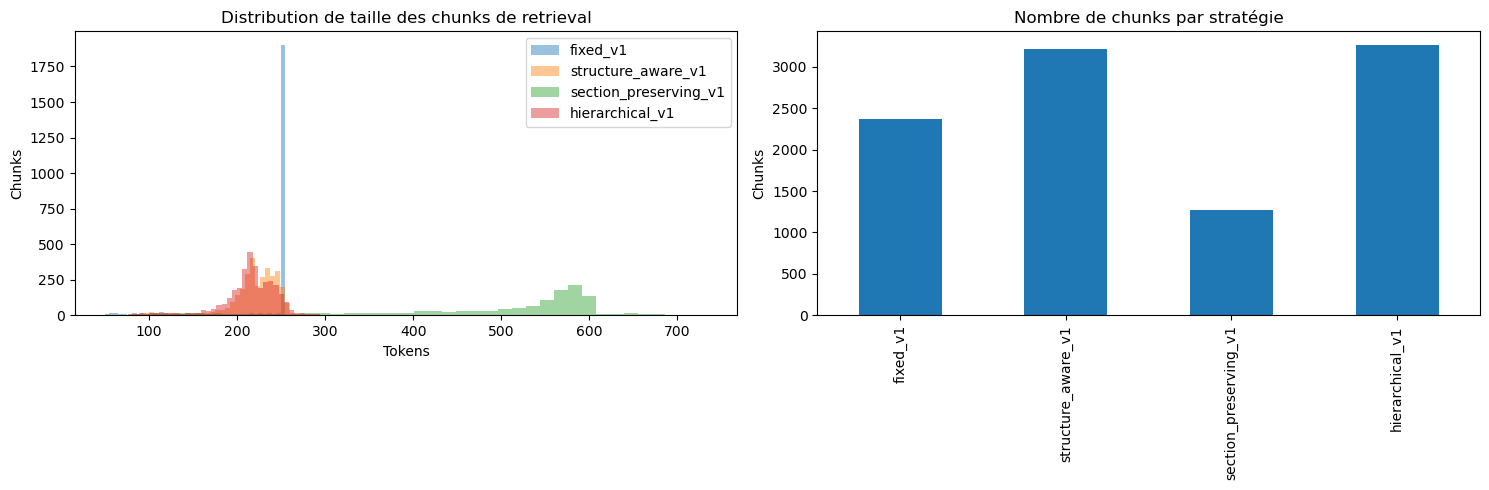

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for strategy_name, strategy_artifacts in artifacts.items():
    values = [chunk["token_count"] for chunk in retrieval_chunks(strategy_artifacts)]
    axes[0].hist(values, bins=40, alpha=0.45, label=strategy_name)
comparison_df["retrieval_chunks"].plot.bar(ax=axes[1])
axes[0].set_title("Distribution de taille des chunks de retrieval")
axes[0].set_xlabel("Tokens")
axes[0].set_ylabel("Chunks")
axes[0].legend()
axes[1].set_title("Nombre de chunks par stratégie")
axes[1].set_xlabel("")
axes[1].set_ylabel("Chunks")
plt.tight_layout()
plt.show()

## 10. Écriture atomique des artefacts expérimentaux

In [13]:
def write_jsonl_atomic(path: Path, records: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8", newline="\n") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")
    temporary.replace(path)


def write_json_atomic(path: Path, value: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    temporary.replace(path)


output_manifests = {}
for strategy_name, strategy_artifacts in artifacts.items():
    strategy_dir = OUTPUT_ROOT / strategy_name
    output_metadata = {}
    for artifact_name, records in strategy_artifacts.items():
        output_path = strategy_dir / f"{artifact_name}.jsonl"
        write_jsonl_atomic(output_path, records)
        output_metadata[output_path.name] = {
            "records": len(records),
            "bytes": output_path.stat().st_size,
            "sha256": file_sha256(output_path),
        }

    manifest = {
        "schema_version": "1.0.0",
        "pipeline_stage": "02_chunking_experiments",
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "experiment_id": experiment_id,
        "strategy": strategy_name,
        "configuration_hash": config_hash,
        "configuration": config["strategies"][strategy_name],
        "tokenizer": config["tokenizer"],
        "input": {
            "path": str(documents_path.relative_to(PROJECT_ROOT)),
            "records": len(documents),
            "sha256": expected_hash,
        },
        "deduplication": {
            "source_documents": len(documents),
            "unique_document_contents": len(document_groups),
            "duplicate_groups": duplicate_groups,
            "copies_avoided": len(documents) - len(document_groups),
        },
        "outputs": output_metadata,
        "metrics": next(row for row in comparison_rows if row["strategy"] == strategy_name),
        "quality": quality_details[strategy_name],
    }
    write_json_atomic(strategy_dir / "manifest.json", manifest)
    output_manifests[strategy_name] = manifest

chunking_report = {
    "schema_version": "1.0.0",
    "pipeline_stage": "02_chunking_experiments",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "experiment_id": experiment_id,
    "implementation_version": config["implementation_version"],
    "configuration_path": str(CONFIG_PATH.relative_to(PROJECT_ROOT)),
    "configuration_hash": config_hash,
    "input_documents": len(documents),
    "unique_document_contents": len(document_groups),
    "source_spans": len(all_span_ids),
    "source_profiles": {
        "document_tokens": documents_tokens_df["tokens"].describe(percentiles=[0.5, 0.95, 0.99]).round(2).to_dict(),
        "section_tokens": sections_tokens_df["tokens"].describe(percentiles=[0.5, 0.95, 0.99]).round(2).to_dict(),
        "span_tokens": spans_tokens_df["tokens"].describe(percentiles=[0.5, 0.95, 0.99]).round(2).to_dict(),
    },
    "strategies": {row["strategy"]: row for row in comparison_rows},
    "quality": quality_details,
    "decision": "experimental_not_final",
}
write_json_atomic(REPORT_ROOT / "chunking_report.json", chunking_report)
print(f"Artefacts : {OUTPUT_ROOT}")
print(f"Rapport   : {REPORT_ROOT / 'chunking_report.json'}")

Artefacts : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\processed\multidoc2dial_v1\chunking_experiments\chunking_candidates_v0_b1ac9cc451
Rapport   : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\reports\generated\multidoc2dial_v1\chunking_experiments\chunking_candidates_v0_b1ac9cc451\chunking_report.json


## 11. Validation après relecture depuis le disque

In [14]:
persisted_report = load_json(REPORT_ROOT / "chunking_report.json")
assert persisted_report["experiment_id"] == experiment_id
assert persisted_report["configuration_hash"] == config_hash
assert persisted_report["decision"] == "experimental_not_final"

for strategy_name in config["strategies"]:
    strategy_dir = OUTPUT_ROOT / strategy_name
    persisted_manifest = load_json(strategy_dir / "manifest.json")
    assert persisted_manifest["quality"]["status"] == "passed"
    assert persisted_manifest["configuration_hash"] == config_hash
    for filename, metadata in persisted_manifest["outputs"].items():
        output_path = strategy_dir / filename
        assert file_sha256(output_path) == metadata["sha256"]
        with output_path.open(encoding="utf-8") as handle:
            assert sum(1 for _ in handle) == metadata["records"]

display(comparison_df)
print("✅ Artefacts expérimentaux valides. Envoie maintenant les résultats à Codex pour adaptation.")

,retrieval_chunks,parents,mean_parent_tokens,small_noninitial_parents,mean_tokens,median_tokens,p95_tokens,max_tokens,small_chunks,chunks_without_span,duplicate_chunk_contents,preserved_sections,fragmented_sections,any_span_coverage,full_span_coverage,status
strategy,,,,,,,,,,,,,,,,
fixed_v1,2370,0,0.00,0,234.20,255.0,255.0,255,0,0,30,NaN,NaN,1.0,0.999804,passed
structure_aware_v1,3219,0,0.00,0,219.34,224.0,254.0,300,0,0,67,NaN,NaN,1.0,1.000000,passed
section_preserving_v1,1273,0,0.00,0,495.07,554.0,600.0,734,0,0,20,13142.0,0.0,1.0,1.000000,passed
hierarchical_v1,3265,867,729.67,0,213.77,217.0,254.0,300,0,0,52,NaN,NaN,1.0,1.000000,passed


✅ Artefacts expérimentaux valides. Envoie maintenant les résultats à Codex pour adaptation.


## 12. Résultats à examiner avant la version finale

Après `Run All`, nous examinerons ensemble :

- les percentiles de taille des documents, sections et spans ;
- les spans dépassant 300 tokens et les sections dépassant 800 tokens ;
- le nombre de chunks de chaque stratégie ;
- les chunks sous `min_tokens` ;
- les chunks sans span annoté ;
- la couverture totale et complète des spans ;
- le nombre de sections conservées entières et réellement fragmentées par `section_preserving_v1` ;
- la distribution des tokens ;
- quelques chunks réels inspectés manuellement.

La mention `experimental_not_final` est volontaire : les paramètres et éventuellement l’algorithme seront adaptés à partir de la première exécution.